In [121]:
import numpy as np
from scipy import constants
import matplotlib.pyplot as plt
import time

DFT is given by

$X[k]=\sum_{n=0}^{N-1}x[n]e^{-j\frac{2\pi kn}{N}}\\
Re(X[k]) = \sum_{n=0}^{N-1}x[n]\cos{\frac{2\pi kn}{N}}\\
Im(X[k]) = -\sum_{n=0}^{N-1}x[n]\sin{\frac{2\pi kn}{N}}$

Where,
N = total sample
k = Frequency Index




In [91]:
def DFT(x):
    x = np.asarray(x, dtype=float)
    N = len(x)
    X = np.zeros(N, dtype=complex)

    for k in range(N):
        re = 0.0
        im = 0.0
        for n in range(N):
            angle = (2 * np.pi * k * n) / N
            re += x[n] * np.cos(angle)
            im -= x[n] * np.sin(angle)
        X[k] = complex(re, im)

    magnitude = np.abs(X)
    phase = np.angle(X)

    return X, magnitude, phase

In [114]:
#Vectorized
def DFTPRO(x):
  N = len(x)
  x = np.asarray(x, dtype=complex)
  n = np.arange(N)
  k = n[:, None]
  w = np.exp(-2j * np.pi * k * n/ N)
  X = w @ x #Matrix multiplication
  return X, np.abs(X), np.angle(X)

In [115]:
#Defining the sine wave parameters
amplitude = 1.0
frequency = 2.0  # Hz
duration = 0.5   # seconds
sampling_rate = 3000.0 # points per second
num_samples = int(sampling_rate * duration)
time = np.linspace(0, duration, num_samples, endpoint=False)
sine_wave = np.array(amplitude * np.sin(2 * np.pi * frequency * time), dtype=float)

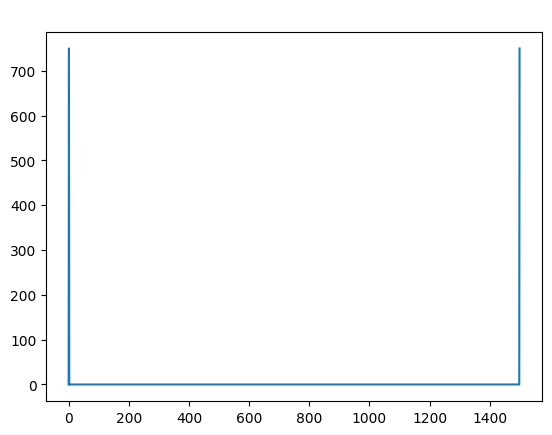

Time needed : 0.2037 s


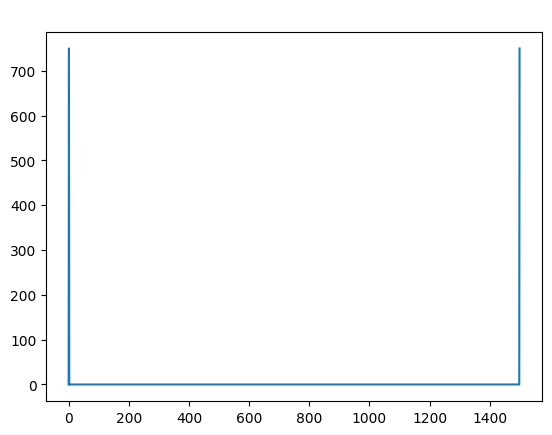

Time needed : 7.5406 s


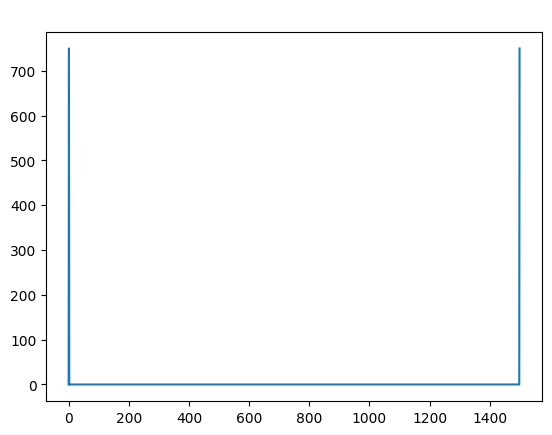

Time needed : 0.0004 s


In [135]:
start_time = time.perf_counter()
X, magnitude, phase = DFTPRO(sine_wave)
end_time = time.perf_counter()
plt.plot(magnitude)
plt.title("DFT under Vectorised Algo")
plt.show()
elapsed = end_time - start_time
print(f'Time needed : {elapsed:.4f} s')

start_time = time.perf_counter()
X, magnitude, phase = DFT(sine_wave)
end_time = time.perf_counter()
plt.plot(magnitude)
plt.title("DFT under Normal Algo")
plt.show()
elapsed = end_time - start_time
print(f'Time needed : {elapsed:.4f} s')

start_time = time.perf_counter()
magnitude = np.abs(np.fft.fft(sine_wave))
end_time = time.perf_counter()
plt.plot(magnitude)
plt.title("DFT under Numpy FFT ")
plt.show()
elapsed = end_time - start_time
print(f'Time needed : {elapsed:.4f} s')